# NT_V3 Concordance Analysis — Plot-by-Plot Notebook

Each section defines a plot function, runs a **single representative call** with explicit parameters, then loops over all subsets/modes.

Assumes `merged` DataFrame is already loaded with columns: `concordance`, `signal_category`, `MLM_category`, `primary_signal_mechanism`, `rationale_mechanism`, `variant_type`, and optionally score columns (`LLR`, `GPN-MSA`, `CADD`, etc.).

---
## Cell 1: Imports, Config, Helpers

Constants, subset definitions, save utilities, and shared statistical functions used by all plot cells.

In [45]:
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from typing import Dict, Optional, List, Tuple, Union
from pathlib import Path

# ── Orders & colors ──────────────────────────────────────────────────
# signal_order / mlm_order: ordinal strength bins assigned by the LLM judge
# conc_order: concordance levels between NT delta signal and ClinVar rationale
DEFAULT_ORDER = ["ABSENT", "WEAK", "MODERATE", "STRONG"]
DEFAULT_CONC_ORDER = ["DISCORDANT", "PARTIAL", "CONCORDANT", "NOT_APPLICABLE"]
CONC_COLORS = {
    "CONCORDANT": "#2ecc71", "PARTIAL": "#f39c12",
    "DISCORDANT": "#e74c3c", "NOT_APPLICABLE": "#95a5a6",
}

# Score columns: conservation / functional scores from BW annotation pipeline
# LLR = NT_V3 log-likelihood ratio (delta); others from bigWig tracks
DEFAULT_SCORE_COLS = [
    "LLR", "GPN-MSA", "CADD", "phyloP-100v",
    "phyloP-241m", "phastCons-100v", "ESM-1b", "NT", "HyenaDNA",
]

DEFAULT_IMPACT_SCORE_COLS = ['gnomADe_AF',
 'BED_mean_abs',
 'BED_max_abs',
 'BED_sum_log',
 'BED_top3_mean',
 'BW_z_mean_abs',
 'BW_z_max_abs',
 'BW_z_sum_log',
 'BW_z_top10_mean',
 'Global_z_mean_abs',
 'Global_z_max_abs',
 'Global_z_sum_log',
 'Composite_mean',
 'Composite_top']


# ── Subset definitions (used by every plot cell) ─────────────────────
# variant_type column comes from ClinVar VCF parsing (snp / indel)
SUBSETS = {
    "ALL":   lambda d: pd.Series(True, index=d.index),
    "SNP":   lambda d: d["variant_type"].eq("snp"),
    "INDEL": lambda d: d["variant_type"].eq("indel"),
}

# ── Output directory ─────────────────────────────────────────────────
REPORT_DIR = Path("ntv3_report")
DPI = 200
FMT = "png"

def _savefig(fig, path):
    p = Path(path); p.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(str(p), dpi=DPI, bbox_inches="tight", facecolor="white")

def _savedf(obj, path):
    p = Path(path); p.parent.mkdir(parents=True, exist_ok=True)
    if isinstance(obj, (pd.DataFrame, pd.Series)):
        obj.to_csv(str(p))
    elif isinstance(obj, dict):
        ct = obj.get("crosstab")
        if ct is not None: ct.to_csv(str(p).replace(".csv","_crosstab.csv"))
        pd.Series({k:v for k,v in obj.items() if k!="crosstab"}).to_csv(
            str(p).replace(".csv","_stats.csv"))

# ── Shared stat helpers ──────────────────────────────────────────────
def _as_ordered_cat(s, order):
    return pd.Categorical(s, categories=order, ordered=True)

def _prep_df(df, concord_col, signal_col, mlm_col,
             signal_order, mlm_order, conc_order):
    out = df.copy()
    for col, order in [(signal_col, signal_order),
                       (mlm_col, mlm_order),
                       (concord_col, conc_order)]:
        out[col] = out[col].astype(str).str.strip().str.upper()
        out[col] = _as_ordered_cat(out[col], order)
    return out

def _safe_crosstab(row_s, col_s, row_order, col_order):
    tmp = pd.DataFrame({"row": row_s.values, "col": col_s.values})
    tmp["row"] = tmp["row"].astype(str).str.strip().str.upper()
    tmp["col"] = tmp["col"].astype(str).str.strip().str.upper()
    ct = pd.crosstab(tmp["row"], tmp["col"], dropna=False)
    ct.index = ct.index.astype(str); ct.columns = ct.columns.astype(str)
    if not ct.index.is_unique:  ct = ct.groupby(level=0).sum()
    if not ct.columns.is_unique: ct = ct.T.groupby(level=0).sum().T
    return ct.reindex(index=row_order, columns=col_order, fill_value=0)

def _ordinal_encode(s, order):
    return s.map({k:i for i,k in enumerate(order)}).astype("float")

def _spearman_rho(x, y):
    if len(x) < 3: return np.nan
    rx = pd.Series(x).rank(method="average").to_numpy()
    ry = pd.Series(y).rank(method="average").to_numpy()
    if np.nanstd(rx)==0 or np.nanstd(ry)==0: return np.nan
    return float(np.corrcoef(rx, ry)[0, 1])

def _cramers_v_from_crosstab(ct):
    obs = ct.to_numpy(); n = obs.sum()
    if n == 0: return np.nan
    exp = obs.sum(1, keepdims=True) @ obs.sum(0, keepdims=True) / n
    with np.errstate(divide="ignore", invalid="ignore"):
        chi2 = np.nansum((obs - exp)**2 / exp)
    r, k = obs.shape; denom = n * (min(r-1, k-1))
    return np.nan if denom <= 0 else float(np.sqrt(chi2 / denom))

print("Helpers loaded.")

# delta files with variants IDs
snps_deltas = pd.read_parquet("parquet/annotated_snps_signaled_impacted.parquet")
indels_deltas = pd.read_parquet("parquet/annotated_indels_signaled_impacted.parquet")
indels_deltas.rename(columns={"variant_id":"#VariationID"}, inplace=True)

# loading LLM results
snps = pd.read_csv("parquet/snp_evaluation_results_v2.csv")
indels = pd.read_csv("parquet/indel_evaluation_results_v2.csv")

# annotating for concatenation
snps["variant_type"] = "snp"
indels["variant_type"] = "indel"
variants = pd.concat([snps, indels])
variants

# --- MERGE snps and indels
cols_from_deltas = list(dict.fromkeys(DEFAULT_SCORE_COLS + DEFAULT_IMPACT_SCORE_COLS + ["#VariationID"]))

merged = pd.merge(
    variants,
    snps_deltas[cols_from_deltas],
    on="#VariationID",
    how="left"
)

# 1) merge indel LLR separately
merged = pd.merge(
    merged,
    indels_deltas[["#VariationID", "LLR"]].rename(columns={"LLR": "LLR_indel"}),
    on="#VariationID",
    how="left"
)

# fill SNP LLR NaNs with indel LLR
merged["LLR"] = merged["LLR"].fillna(merged["LLR_indel"])

# 2) merge other indel impact-score cols under temp names
impact_cols_no_llr = [c for c in DEFAULT_IMPACT_SCORE_COLS if c != "LLR"]

if impact_cols_no_llr:
    indels_tmp = indels_deltas[["#VariationID"] + impact_cols_no_llr].rename(
        columns={c: f"{c}_indel" for c in impact_cols_no_llr}
    )

    merged = pd.merge(
        merged,
        indels_tmp,
        on="#VariationID",
        how="left"
    )

    # 3) fill NaNs in SNP impact cols from indel cols
    for c in impact_cols_no_llr:
        merged[c] = merged[c].fillna(merged[f"{c}_indel"])

    # 4) drop temp impact cols
    merged = merged.drop(columns=[f"{c}_indel" for c in impact_cols_no_llr])

# drop helper LLR column
merged = merged.drop(columns=["LLR_indel"])


Helpers loaded.


---
## Cell 2: Mechanism Canonicalization

Regex-based bucketing of free-text mechanism labels into standardized categories.

- **Primary mechanism**: what the NT model signal suggests (MLM / splice / truncation / etc.)
- **Rationale mechanism**: what ClinVar reviewers cited as the pathogenic mechanism

Applied in-place to `merged` — run once before all plot cells.

In [88]:
# ── Primary mechanism canonicalizer ───────────────────────────────────

def build_primary_mechanism_canonicalizer(
    merge_mlm_like=True,
    mlm_bucket_name="MLM / Sequence-constraint signal",
    model_favors_bucket_name="Model favors variant",
):
    CANON = {
        model_favors_bucket_name: [
            r"\bmodel favou?rs variant\b", r"\bmodel favou?rs the variant\b"],
        "Benign / Neutral / None": [
            r"\bnone detected\b", r"\bnone identified\b", r"\bno mechanism detected\b",
            r"\bneutral\b", r"\bbenign\b", r"\btolerated\b",
            r"\bsilent\b", r"\bsynonymous\b"],
        "Uncertain / Unknown": [
            r"\bunknown\b", r"\buncertain\b", r"\bundetermined\b",
            r"\binconclusive\b", r"\bunclear\b", r"\bna\b"],
        "Pharmacogenomic": [r"\bpharmacogen", r"\bdrug response\b", r"\bpharmacogenetic\b"],
        "Splicing": [
            r"\bsplice\b", r"\bsplicing\b", r"\bdonor\b", r"\bacceptor\b",
            r"\bexon skipping\b", r"\bintron retention\b", r"\bcryptic splice\b",
            r"\bpseudoexon\b", r"\bexon[- ]intron boundary\b",
            r"\bexon\b", r"\bintron\b"],
        "Start codon / Initiation / ORF": [
            r"\bstart codon\b", r"\bstart[- ]?loss\b",
            r"\binitiation\b", r"\btranslation initiation\b",
            r"\binitiator\b", r"\borf\b"],
        "Nonsense / Truncation / NMD": [
            r"\bnonsense\b", r"\bstop[- ]?gain\b", r"\bpremature stop\b",
            r"\btruncat", r"\bnmd\b", r"\btermination codon\b"],
        "Stop-loss / Protein extension": [
            r"\bstop[- ]?loss\b", r"\bprotein extension\b"],
        "Regulatory / Expression": [
            r"\bregulatory\b", r"\bexpression\b", r"\btranscription\b",
            r"\bcage\b", r"\b3'\s*utr\b", r"\b5'\s*utr\b",
            r"\bdownregulat", r"\bupregulat"],
        "3' UTR": [r"\b3'\s*utr\b"], "5' UTR": [r"\b5'\s*utr\b"],
        "UTR": [r"\butr\b"],
        mlm_bucket_name: [
            r"\bmlm\b", r"\bllr\b", r"\blogprob\b", r"\bprior\b", r"\bdelta\b",
            r"\bsequence plausibility\b", r"\bsequence preference\b",
            r"\bsequence disruption\b", r"\bsequence context\b",
            r"\bconstraint\b", r"\bintoler", r"\bconservation\b",
            r"\bevolutionary\b", r"\bconserved\b",
            r"\bmissense\b", r"\bamino acid\b",
            r"\bprotein\b", r"\bprotein[- ]level\b", r"\bprotein[- ]coding\b",
            r"\bcoding sequence\b", r"\bcoding\b",
            r"\bprotein function\b", r"\bprotein functional\b",
            r"\bprotein structural\b",
            r"\bnon[- ]?synonymous\b", r"\bcoding disruption\b"],
    }
    PRIORITY = [
        model_favors_bucket_name, "Benign / Neutral / None", "Uncertain / Unknown",
        "Pharmacogenomic", "Splicing", "Start codon / Initiation / ORF",
        "Nonsense / Truncation / NMD", "Stop-loss / Protein extension",
        "Regulatory / Expression", mlm_bucket_name,
    ]
    if not merge_mlm_like:
        CANON[mlm_bucket_name] = [
            r"\bmlm\b", r"\bllr\b", r"\blogprob\b",
            r"\bsequence plausibility\b", r"\bsequence preference\b"]
    CANON_RE = {k: [re.compile(p, re.I) for p in pats] for k, pats in CANON.items()}
    EFFECT_GUARD_RE = re.compile(
        r"\b(model favou?rs variant|non[- ]?synonymous|coding disruption|"
        r"missense|amino acid|protein|coding|mlm|llr|logprob|prior|delta|"
        r"constraint|conservation|conserved|evolutionary|intoler|"
        r"splice|splicing|donor|acceptor|nmd|nonsense|"
        r"stop[- ]?gain|stop[- ]?loss|truncat)\b", re.I)

    def _canonicalize(label):
        if label is None or (isinstance(label, float) and pd.isna(label)):
            return "Uncertain / Unknown"
        s = str(label).strip()
        if not s: return "Uncertain / Unknown"
        s_norm = s.replace("_"," ").replace("|"," ").replace(","," ").lower()
        benign_hit = any(rx.search(s_norm) for rx in CANON_RE["Benign / Neutral / None"])
        if benign_hit and EFFECT_GUARD_RE.search(s_norm):
            for bucket in [b for b in PRIORITY if b != "Benign / Neutral / None"]:
                for rx in CANON_RE[bucket]:
                    if rx.search(s_norm): return bucket
            return "Other / Unclassified"
        for bucket in PRIORITY:
            for rx in CANON_RE[bucket]:
                if rx.search(s_norm): return bucket
        return "Other / Unclassified"
    return _canonicalize


# ── Rationale mechanism canonicalizer ────────────────────────────────

def build_rationale_mechanism_canonicalizer():
    CANON = {
        "Splicing": [
            r"\bsplice\b", r"\bsplicing\b", r"\bdonor\b", r"\bacceptor\b",
            r"\bexon skipping\b", r"\bintron retention\b", r"\bcryptic splice\b"],
        "Start codon / Initiation / ORF": [
            r"\bstart codon\b", r"\bstart[- ]?loss\b",
            r"\binitiation\b", r"\btranslation initiation\b", r"\borf\b"],
        "Nonsense / Truncation / NMD": [
            r"\bnonsense\b", r"\bstop[- ]?gain\b", r"\bpremature stop\b",
            r"\btruncat", r"\bnmd\b"],
        "Stop-loss / Protein extension": [
            r"\bstop[- ]?loss\b", r"\bprotein extension\b"],
        "Frameshift": [r"\bframeshift\b"],
        "Pharmacogenomic": [r"\bpharmacogen", r"\bdrug response\b"],
        "Regulatory / Transcriptional": [
            r"\bregulatory\b", r"\btranscription\b", r"\bcage\b",
            r"\bdownregulat", r"\bupregulat", r"\bexpression\b",
            r"\btranscriptional\b"],
        "3' UTR": [r"3'\s*utr"], "5' UTR": [r"5'\s*utr"],
        "UTR": [r"\butr\b"],
        "Missense / Protein function": [
            r"\bmissense\b", r"\bamino acid\b",
            r"\bprotein function\b", r"\bprotein structural\b",
            r"\bgain[- ]of[- ]function\b", r"\bloss[- ]of[- ]function\b",
            r"\bdominant[- ]negative\b"],
        "Sequence constraint / Conservation": [
            r"\bconstraint\b", r"\bconservation\b", r"\bconserved\b",
            r"\bevolutionary\b", r"\bintoler",
            r"\bsequence conservation\b", r"\bsequence constraint\b",
            r"\bprotein[- ]?level\b", r"\bprotein[- ]?coding\b",
            r"\bcoding sequence\b", r"\bcoding\b", r"\bsequence\b"],
        "Benign / Neutral / None": [
            r"\bnone\b", r"\bnone detected\b", r"\bneutral\b",
            r"\bbenign\b", r"\btolerated\b", r"\bsilent\b",
            r"\bsynonymous\b", r"\bminimal\b", r"\bno significant\b",
            r"\bno functional\b"],
        "Uncertain / Unknown": [
            r"\bunknown\b", r"\buncertain\b", r"\bundetermined\b",
            r"\binconclusive\b", r"\bunclear\b"],
    }
    PRIORITY = [
        "Splicing", "Start codon / Initiation / ORF",
        "Nonsense / Truncation / NMD", "Stop-loss / Protein extension",
        "Frameshift", "Pharmacogenomic", "Regulatory / Transcriptional",
        "3' UTR", "5' UTR", "UTR",
        "Missense / Protein function", "Sequence constraint / Conservation",
        "Benign / Neutral / None", "Uncertain / Unknown",
    ]
    CANON_RE = {k: [re.compile(p, re.I) for p in pats] for k, pats in CANON.items()}
    EFFECT_GUARD_RE = re.compile(
        r"\b(constraint|conservation|conserved|evolutionary|intoler|"
        r"splice|splicing|donor|acceptor|nmd|nonsense|truncat|"
        r"missense|amino acid|protein[- ]?function|protein[- ]?structural|"
        r"protein[- ]?coding|coding sequence|coding disruption|"
        r"regulatory|transcription|cage|"
        r"start codon|initiation|orf|frameshift)\b", re.I)
    _SOFT = (r"sequence|variant|effect|impact|change|variation|context"
             r"|perturbation|evolution|neutrality|non[- ]?functional"
             r"|disruption|no|functional|significant")
    NEUTRAL_DOM_RE = re.compile(
        r"^\s*(neutral|none|benign|minimal|no significant|no functional|sequence neutrality)"
        r"(\s*/\s*(neutral|none|minimal|no\s+\w+))?"
        r"(\s+(" + _SOFT + r"))*\s*$", re.I)

    def _canonicalize(label):
        if label is None or (isinstance(label, float) and pd.isna(label)):
            return "Uncertain / Unknown"
        s = str(label).strip()
        if not s: return "Uncertain / Unknown"
        s_norm = s.replace("_"," ").replace("|"," ").replace(","," ").lower()
        if NEUTRAL_DOM_RE.match(s_norm): return "Benign / Neutral / None"
        benign_hit = any(rx.search(s_norm) for rx in CANON_RE["Benign / Neutral / None"])
        if benign_hit and EFFECT_GUARD_RE.search(s_norm):
            for bucket in [b for b in PRIORITY if b != "Benign / Neutral / None"]:
                for rx in CANON_RE[bucket]:
                    if rx.search(s_norm): return bucket
            return "Other / Unclassified"
        for bucket in PRIORITY:
            for rx in CANON_RE[bucket]:
                if rx.search(s_norm): return bucket
        return "Other / Unclassified"
    return _canonicalize


# ── Apply canonicalization ───────────────────────────────────────────
primary_canon  = build_primary_mechanism_canonicalizer()
rationale_canon = build_rationale_mechanism_canonicalizer()

merged["primary_signal_mechanism_raw"]  = merged["primary_signal_mechanism"]
merged["rationale_mechanism_raw"]       = merged["rationale_mechanism"]
merged["primary_signal_mechanism"]      = merged["primary_signal_mechanism"].map(primary_canon)
merged["rationale_mechanism"]           = merged["rationale_mechanism"].map(rationale_canon)

print("Mechanisms canonicalized.")
print(merged["primary_signal_mechanism"].value_counts())

Mechanisms canonicalized.
primary_signal_mechanism
MLM / Sequence-constraint signal    10675
Start codon / Initiation / ORF       3780
Benign / Neutral / None              2838
Other / Unclassified                 2530
Regulatory / Expression              1406
Splicing                              521
Uncertain / Unknown                   297
Nonsense / Truncation / NMD            40
Name: count, dtype: int64


---

## Plot 1: Concordance by Variant Type

Stacked bar chart showing concordance fractions (CONCORDANT + PARTIAL) per variant type (SNP vs INDEL). Solid fill = CONCORDANT, hatched fill = PARTIAL.

**Parameters to vary:**
- `variant_order`: list of variant types to include; default `["snp", "indel"]`
- `colors`: dict mapping variant type to bar color; default `{"snp": "green", "indel": "blue"}`
- `normalize`: `True` → fractions (default), `False` → raw counts
- `conc_levels`: concordance levels to stack; default `["CONCORDANT", "PARTIAL"]`

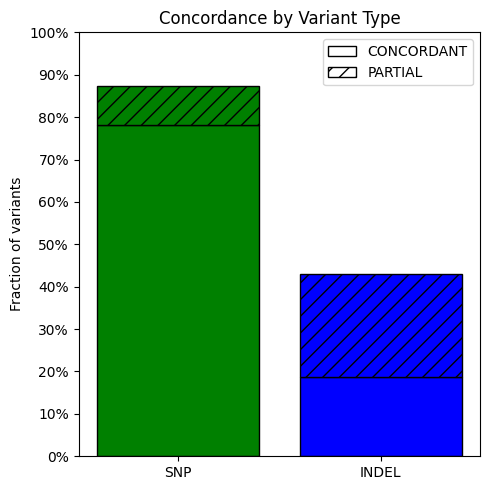

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch # Imported for custom legend handles

# (Assuming 'merged' dataframe is defined earlier in your code)
variant_order = ["snp", "indel"]

# counts
counts = (
    merged.groupby(["variant_type", "concordance"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=variant_order)
)

# convert to fractions over ALL variants
frac = counts.div(counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(5,5))

colors = {"snp": "green", "indel": "blue"} 

for i, vt in enumerate(variant_order):

    c = frac.loc[vt, "CONCORDANT"]
    p = frac.loc[vt, "PARTIAL"]

    # solid concordant (removed the label argument)
    ax.bar(i, c, color=colors[vt], edgecolor="black")

    # hatched partial stacked above (removed the label argument)
    ax.bar(i, p, bottom=c, color=colors[vt], edgecolor="black", hatch="//")

# axis formatting
ax.set_xticks([0,1])
ax.set_xticklabels(["SNP","INDEL"])

ax.set_ylim(0,1)

# percent ticks every 10%
ticks = np.arange(0,1.01,0.1)
ax.set_yticks(ticks)
ax.set_yticklabels([f"{int(t*100)}%" for t in ticks])

ax.set_ylabel("Fraction of variants")
ax.set_title("Concordance by Variant Type")

# Create custom legend handles with 'white' (or 'none') facecolor
legend_elements = [
    Patch(facecolor='white', edgecolor='black', label='CONCORDANT'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='PARTIAL')
]

# Apply the custom handles to the legend
ax.legend(handles=legend_elements)

plt.tight_layout()
filename = "overall_concordance"
address = REPORT_DIR / filename
plt.savefig(address)
    
plt.show()

---

## Plot 2: Concordance Bars by Strength Axis

Grouped bar chart showing concordance-level fractions within each strength bin.
Supports both categorical grouping columns (e.g. signal/MLM category) and numeric score columns (auto-binned into quartiles).

**Parameters to vary:**
- `group_col`: any categorical column (`"signal_category"`, `"MLM_category"`) **or** any score column from `SCORE_COLS` (e.g. `"Global_z_sum_log"`, `"Composite_mean"`) — score columns are auto-binned into quartiles
- `normalize`: `True` → fractions (default), `False` → raw counts
- `group_order`: defaults to `DEFAULT_ORDER` for categories, `["Q1","Q2","Q3","Q4"]` for scores
- `conc_order` / `conc_colors`: concordance levels and their colors
- `use_quantile_binning_for_scores`: `True` (default) — quartile-bin any `SCORE_COLS` column; `False` → treat as-is

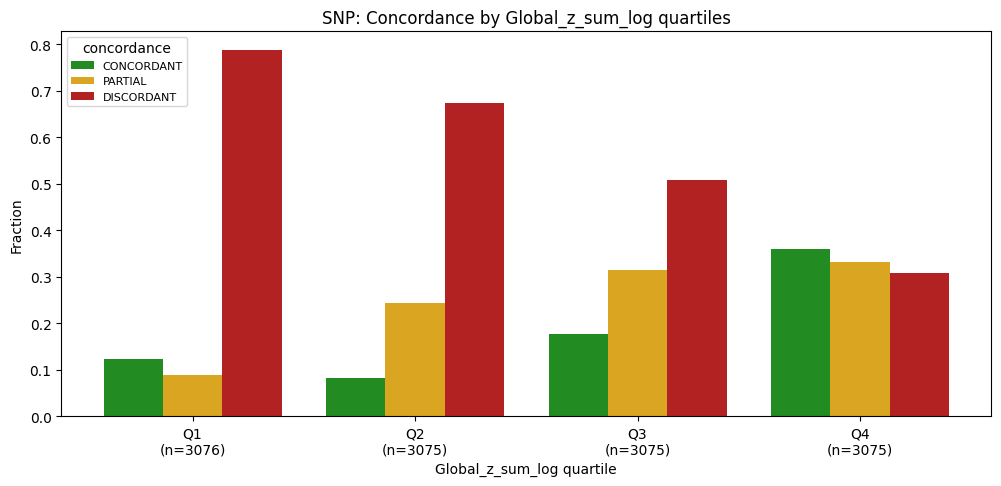

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SCORE_COLS = [
    "BED_mean_abs",
    "BED_max_abs",
    "BED_sum_log",
    "BED_top3_mean",
    "BW_z_mean_abs",
    "BW_z_max_abs",
    "BW_z_sum_log",
    "BW_z_top10_mean",
    "Global_z_mean_abs",
    "Global_z_max_abs",
    "Global_z_sum_log",
    "Composite_mean",
    "Composite_top",
]

DEFAULT_QUARTILE_ORDER = ["Q1", "Q2", "Q3", "Q4"]


def _safe_crosstab(row_vals, col_vals, row_order, col_order):
    ct = pd.crosstab(row_vals, col_vals)
    ct = ct.reindex(index=row_order, columns=col_order, fill_value=0)
    return ct


def _make_quartile_groups(
    series: pd.Series,
    labels=DEFAULT_QUARTILE_ORDER,
    duplicates="drop",
):
    """
    Convert a numeric series into quartile labels.
    Returns a categorical series with labels like Q1/Q2/Q3/Q4.
    """
    s = pd.to_numeric(series, errors="coerce")
    out = pd.Series(index=s.index, dtype="object")

    valid = s.notna()
    if valid.sum() == 0:
        return out

    try:
        out.loc[valid] = pd.qcut(
            s.loc[valid],
            q=4,
            labels=labels,
            duplicates=duplicates,
        ).astype(str)
    except ValueError:
        # fallback if too few unique values
        ranked = s.loc[valid].rank(method="average", pct=True)
        bins = [0, 0.25, 0.5, 0.75, 1.0]
        out.loc[valid] = pd.cut(
            ranked,
            bins=bins,
            labels=labels,
            include_lowest=True,
        ).astype(str)

    return out


def plot_concordance_bars(
    df,
    group_col="signal_category",
    concord_col="concordance",
    group_order=None,
    conc_order=("CONCORDANT", "PARTIAL", "DISCORDANT"),
    conc_colors=None,
    normalize=True,
    figsize=(12, 5),
    title=None,
    ax=None,
    score_cols=SCORE_COLS,
    quartile_labels=DEFAULT_QUARTILE_ORDER,
    use_quantile_binning_for_scores=True,
):
    """
    Plot concordance by either:
    1. a categorical grouping column (e.g. signal_category, MLM_category), or
    2. a numeric score column, which will be stratified into quartiles.

    Parameters
    ----------
    group_col : str
        Either a categorical column name or one of score_cols.
    group_order : list or None
        For categorical mode: explicit category order.
        For score mode: defaults to quartile_labels.
    use_quantile_binning_for_scores : bool
        If True and group_col is in score_cols, bin into quartiles.
    """
    d = df.copy()
    d[concord_col] = d[concord_col].astype(str).str.strip().str.upper()

    # default colors
    if conc_colors is None:
        conc_colors = {
            "CONCORDANT": "forestgreen",
            "PARTIAL": "goldenrod",
            "DISCORDANT": "firebrick",
        }

    # decide grouping mode
    is_score_mode = group_col in score_cols and use_quantile_binning_for_scores

    if is_score_mode:
        group_label = f"{group_col}_quartile"
        d[group_label] = _make_quartile_groups(d[group_col], labels=quartile_labels)
        d[group_label] = d[group_label].astype(str).str.strip().str.upper()
        group_order_final = [q.upper() for q in quartile_labels] if group_order is None else group_order
        plot_group_col = group_label
        xlabel = f"{group_col} quartile"
    else:
        d[group_col] = d[group_col].astype(str).str.strip().str.upper()
        plot_group_col = group_col
        if group_order is None:
            group_order_final = list(pd.Index(d[group_col].dropna().unique()))
        else:
            group_order_final = group_order
        xlabel = group_col

    conc_order = [c.upper() for c in conc_order]

    ct = _safe_crosstab(
        d[plot_group_col],
        d[concord_col],
        group_order_final,
        conc_order,
    )

    if normalize:
        plot_df = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
        ylabel = "Fraction"
    else:
        plot_df = ct.copy()
        ylabel = "Count"

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    x = np.arange(len(group_order_final))
    n_bars = len(conc_order)
    width = 0.8 / n_bars

    for i, conc in enumerate(conc_order):
        if conc not in plot_df.columns:
            continue
        ax.bar(
            x + i * width - 0.4 + width / 2,
            plot_df[conc].values,
            width,
            label=conc,
            color=conc_colors.get(conc),
        )

    row_totals = ct.sum(axis=1)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{g}\n(n={int(row_totals.get(g, 0))})" for g in group_order_final])
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.legend(title=concord_col, fontsize=8, loc="upper left")

    if title is None:
        suffix = " — normalized" if normalize else ""
        title = f"Concordance by {xlabel} (N={len(d)}){suffix}"
    ax.set_title(title)

    return fig, ax, plot_df
    
dsub_snp = merged.loc[SUBSETS["INDEL"](merged)].copy()
fig, ax, df_out = plot_concordance_bars(
    dsub_snp,
    group_col="Global_z_sum_log",
    normalize=True,
    title="SNP: Concordance by Global_z_sum_log quartiles",
)
plt.show()


---

## Plot 3: LLR vs Score Scatter

Per-variant-type scatter of LLR against a chosen NT score column, with a running-median trend line overlaid.

**Parameters to vary:**
- `score_col`: any numeric column to plot on x-axis (e.g. `"Global_z_sum_log"`, `"Composite_top"`, `"BED_mean_abs"`)
- `llr_col`: y-axis metric; default `"LLR"`
- `variant_types`: tuple of variant types to panel; default `("snp", "indel")`
- `max_points`: subsample cap per panel to keep scatter readable; default `15000`
- `alpha` / `point_size`: scatter aesthetics
- `n_bins`: number of bins for the running-median trend; default `30`

C:\Users\stavz\AppData\Local\Temp\ipykernel_12740\1993209351.py:50: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d = d.replace([np.inf, -np.inf], np.nan)


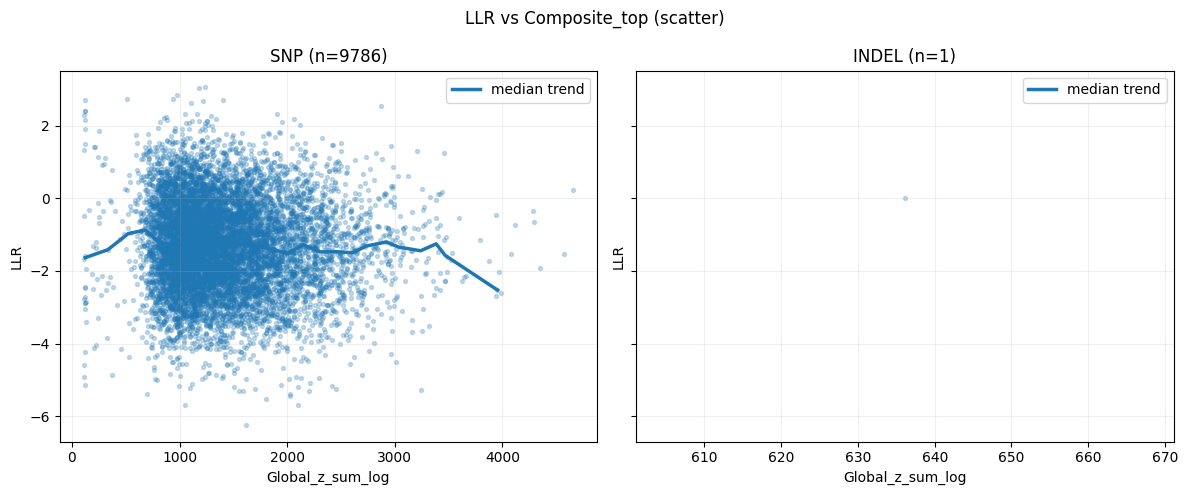

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _running_median(x, y, n_bins=30):
    """Compute running median of y across x bins."""
    bins = np.linspace(np.nanmin(x), np.nanmax(x), n_bins + 1)
    inds = np.digitize(x, bins) - 1

    xm, ym = [], []
    for i in range(n_bins):
        mask = inds == i
        if np.sum(mask) < 5:
            continue
        xm.append(np.median(x[mask]))
        ym.append(np.median(y[mask]))

    return np.array(xm), np.array(ym)
    

def plot_llr_vs_score_scatter(
    df,
    score_col,
    llr_col="LLR",
    variant_col="variant_type",
    variant_types=("snp", "indel"),
    max_points=15000,
    alpha=0.25,
    point_size=8,
    n_bins=30,
    figsize=(12,5),
    title=None,
):
    
    fig, axes = plt.subplots(1, len(variant_types), figsize=figsize, sharey=True)

    if len(variant_types) == 1:
        axes = [axes]

    trend_out = {}

    for ax, vt in zip(axes, variant_types):

        d = df.loc[df[variant_col].str.lower() == vt].copy()

        d[score_col] = pd.to_numeric(d[score_col], errors="coerce")
        d[llr_col] = pd.to_numeric(d[llr_col], errors="coerce")

        d = d.replace([np.inf, -np.inf], np.nan)
        d = d.dropna(subset=[score_col, llr_col])

        # optional subsample to avoid huge scatter
        if len(d) > max_points:
            d = d.sample(max_points, random_state=1)

        x = d[score_col].values
        y = d[llr_col].values

        ax.scatter(
            x, y,
            s=point_size,
            alpha=alpha
        )

        # running median trend
        xm, ym = _running_median(x, y, n_bins=n_bins)

        ax.plot(xm, ym, linewidth=2.5, label="median trend")

        ax.set_title(f"{vt.upper()} (n={len(d)})")
        ax.set_xlabel(score_col)
        ax.set_ylabel(llr_col)
        ax.grid(alpha=0.2)

        ax.legend()

        trend_out[vt] = pd.DataFrame({
            "score": xm,
            "median_llr": ym
        })

    if title is None:
        title = f"{llr_col} vs {score_col}"

    fig.suptitle(title)
    fig.tight_layout()

    return fig, axes, trend_out

SCORE_COL = "Global_z_sum_log"
LLR_COL = "LLR"
fig, axes, trend = plot_llr_vs_score_scatter(
    merged,
    score_col=SCORE_COL,
    llr_col=LLR_COL,
    title="LLR vs Composite_top (scatter)"
)

filename = f"{SCORE_COL} vs {LLR_COL}.png"  
save_dir = REPORT_DIR / "MLM vs SCORE"

# Use pathlib to create the directory safely

address = save_dir / filename
_savefig(fig, address)


plt.show()

---
## Plot 4: Concordance Breakdown per Mechanism Bucket

Stacked horizontal bar: for each mechanism, what fraction is CONCORDANT vs DISCORDANT vs PARTIAL vs N/A. Sorted by total count descending.

**Parameters to vary:**
- `mechanism_col`: `"rationale_mechanism"` or `"primary_signal_mechanism"`
- `top_k`: number of mechanism buckets (default 15)
- `min_count`: require a minimal N observations

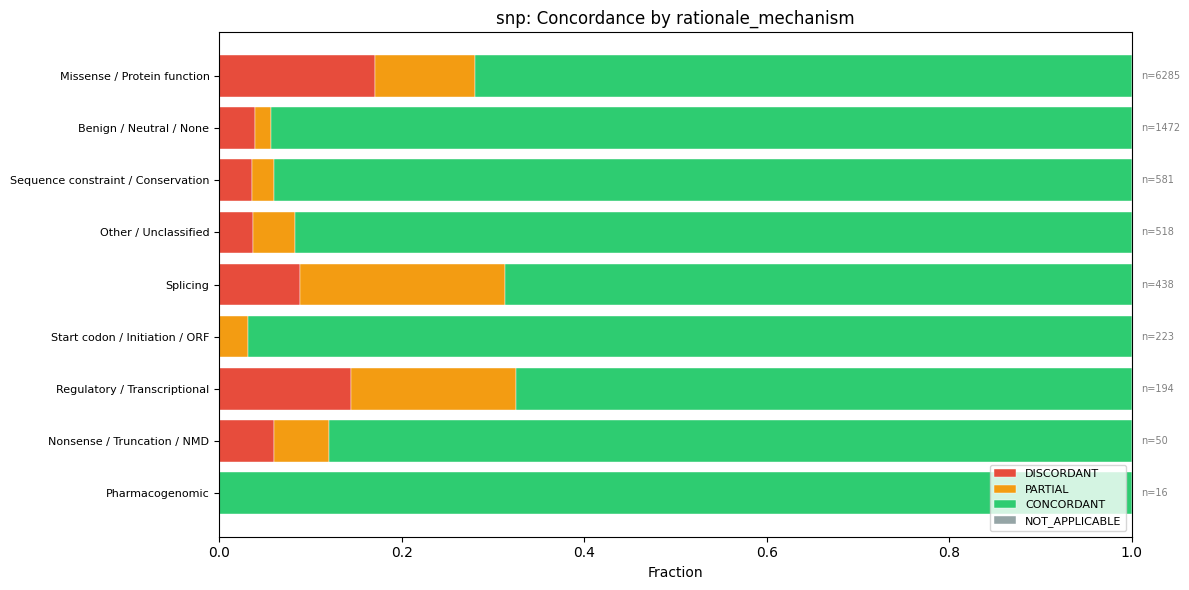

In [89]:
def plot_concordance_by_mechanism(
    df,
    variant_type = "all",
    mechanism_col="rationale_mechanism",
    concord_col="concordance",
    conc_order=DEFAULT_CONC_ORDER,
    conc_colors=CONC_COLORS,
    top_k=15,
    min_count=None,   # <- new
    figsize=(12, 6),
    title=None,
):

    d = df.copy()
    if variant_type != "all":
        d = d[d["variant_type"] == variant_type]
    
    d[concord_col] = d[concord_col].astype(str).str.strip().str.upper()
    d[mechanism_col] = d[mechanism_col].astype(str).str.strip()

    ct = pd.crosstab(d[mechanism_col], d[concord_col], dropna=False)

    for c in conc_order:
        if c not in ct.columns:
            ct[c] = 0
    ct = ct[conc_order]

    # total count per mechanism
    totals = ct.sum(axis=1)

    # optional minimal count filter
    if min_count is not None:
        keep = totals >= min_count
        ct = ct.loc[keep]
        totals = totals.loc[keep]

    # sort by total count descending
    ct = ct.loc[totals.sort_values(ascending=False).index]
    totals = ct.sum(axis=1)

    # optional top-k after filtering
    if top_k is not None and len(ct) > top_k:
        ct = ct.head(top_k)
        totals = totals.head(top_k)

    denom = totals.replace(0, np.nan)
    frac = ct.div(denom, axis=0).fillna(0)

    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(frac))
    left = np.zeros(len(frac))

    frac_rev = frac.iloc[::-1]
    totals_rev = totals.iloc[::-1]

    for c in conc_order:
        if c not in frac_rev.columns:
            continue
        vals = frac_rev[c].values
        ax.barh(
            y, vals, left=left, label=c,
            color=conc_colors.get(c), edgecolor="white", linewidth=0.3
        )
        left += vals

    ax.set_yticks(y)
    ax.set_yticklabels(frac_rev.index, fontsize=8)
    ax.set_xlabel("Fraction")
    ax.set_xlim(0, 1)

    for i, n in enumerate(totals_rev.values):
        ax.text(1.01, i, f"n={int(n)}", va="center", ha="left",
                fontsize=7, color="grey")

    ax.legend(fontsize=8, loc="lower right")
    ax.set_title(title or f"Concordance breakdown per {mechanism_col}")
    fig.tight_layout()
    return fig, ax, frac

VARIANT_TYPE = "snp" # snp / indel / all
MECHANISM_COL = "rationale_mechanism"
fig, ax, df_out = plot_concordance_by_mechanism(
    merged,
    variant_type = VARIANT_TYPE,
    mechanism_col=MECHANISM_COL,
    top_k=15,
    min_count=10,
    title=f"{VARIANT_TYPE}: Concordance by {MECHANISM_COL}",
)
plt.show()